<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ICS40125 - Laboratorio N°09

**Objetivo**: Aplicar un flujo completo de **Machine Learning supervisado** para la clasificación de tumores mamarios, utilizando técnicas de preprocesamiento, reducción de dimensionalidad y modelos de clasificación con optimización de hiperparámetros.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.





<img src="https://www.svgrepo.com/show/1064/virus.svg" width = "300" align="center"/>



El **cáncer de mama** es una enfermedad caracterizada por la proliferación maligna de células epiteliales en los conductos o lobulillos mamarios. Surge cuando una célula acumula mutaciones que le otorgan la capacidad de dividirse de manera descontrolada, lo que da origen a un tumor. Este tumor puede permanecer localizado o, en casos más agresivos, invadir tejidos cercanos y propagarse a otras partes del organismo mediante metástasis.

El conjunto de datos **`BC.csv`** recopila información clínica y morfológica de pacientes con tumores mamarios, clasificados como **benignos** o **malignos**. Las características se obtienen a partir de imágenes digitalizadas de aspirados con aguja fina (FNA, por sus siglas en inglés) de masas mamarias. Dichas variables describen aspectos cuantitativos de los **núcleos celulares**, como su tamaño, forma, textura y homogeneidad.

Este tipo de información es fundamental para la detección temprana y clasificación de tumores, ya que permite entrenar modelos de **machine learning** capaces de apoyar el diagnóstico y diferenciar entre tumores benignos y malignos con mayor precisión.

A continuación, se procederá a cargar y explorar el conjunto de datos:



In [1]:
# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importar herramientas de Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Configuración de gráficos
%matplotlib inline
sns.set_palette("deep", desat=0.6)
sns.set(rc={'figure.figsize': (11.7, 8.27)})

# Cargar y preparar los datos
df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/BC.csv")
df.set_index('id', inplace=True)

# Transformación de la variable objetivo
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0}).astype(int)

# Visualizar las primeras filas del DataFrame
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Con base en la información presentada, resuelva las siguientes tareas. Asegúrese de:

* Incluir el **código necesario** para ejecutar cada análisis.
* Explicar de manera **clara y fundamentada** los resultados obtenidos.
* Describir el **proceso seguido**, justificando las decisiones tomadas en cada etapa (preprocesamiento, elección de técnicas y parámetros, interpretación de resultados).





1. **Análisis exploratorio profundo (EDA):**

   * Examine la distribución de las variables, identifique valores atípicos y analice la correlación entre características.
   * Visualice las diferencias más relevantes entre tumores **benignos** y **malignos** utilizando gráficos adecuados (boxplots, histogramas, mapas de calor).
   * Discuta qué variables parecen tener mayor capacidad discriminativa.


INFORMACIÓN GENERAL
Dimensiones: (569, 31)
Variables: 30 predictoras + 1 target

Distribución de diagnóstico:
diagnosis
0    357
1    212
Name: count, dtype: int64

Proporción de malignos: 37.3%

Valores nulos: 0
Duplicados: 0

RESUMEN ESTADÍSTICO (primeras variables)
       diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
count    569.000      569.000       569.000         569.000    569.000   
mean       0.373       14.127        19.290          91.969    654.889   
std        0.484        3.524         4.301          24.299    351.914   
min        0.000        6.981         9.710          43.790    143.500   
25%        0.000       11.700        16.170          75.170    420.300   
50%        0.000       13.370        18.840          86.240    551.100   
75%        1.000       15.780        21.800         104.100    782.700   
max        1.000       28.110        39.280         188.500   2501.000   

       smoothness_mean  
count          569.000  
mean          

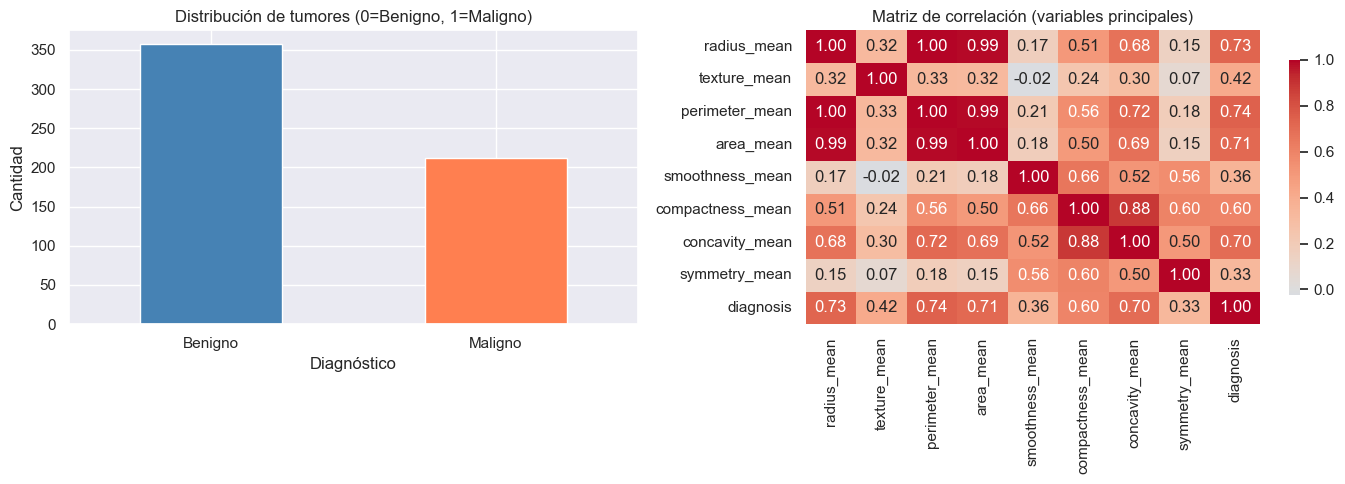

/var/folders/jj/pdvxq45x1wv7z_r03kz_sbcm0000gn/T/ipykernel_49537/2647454315.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y=var, data=df, ax=axes[row, col],
/var/folders/jj/pdvxq45x1wv7z_r03kz_sbcm0000gn/T/ipykernel_49537/2647454315.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[row, col].set_xticklabels(['Benigno', 'Maligno'])
/var/folders/jj/pdvxq45x1wv7z_r03kz_sbcm0000gn/T/ipykernel_49537/2647454315.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y=var, data=df, ax=axes[row, col],
/var/folders/jj/pdvxq45x1wv7z_r03kz_sbcm0000gn/T/ipykernel_49537/2647454

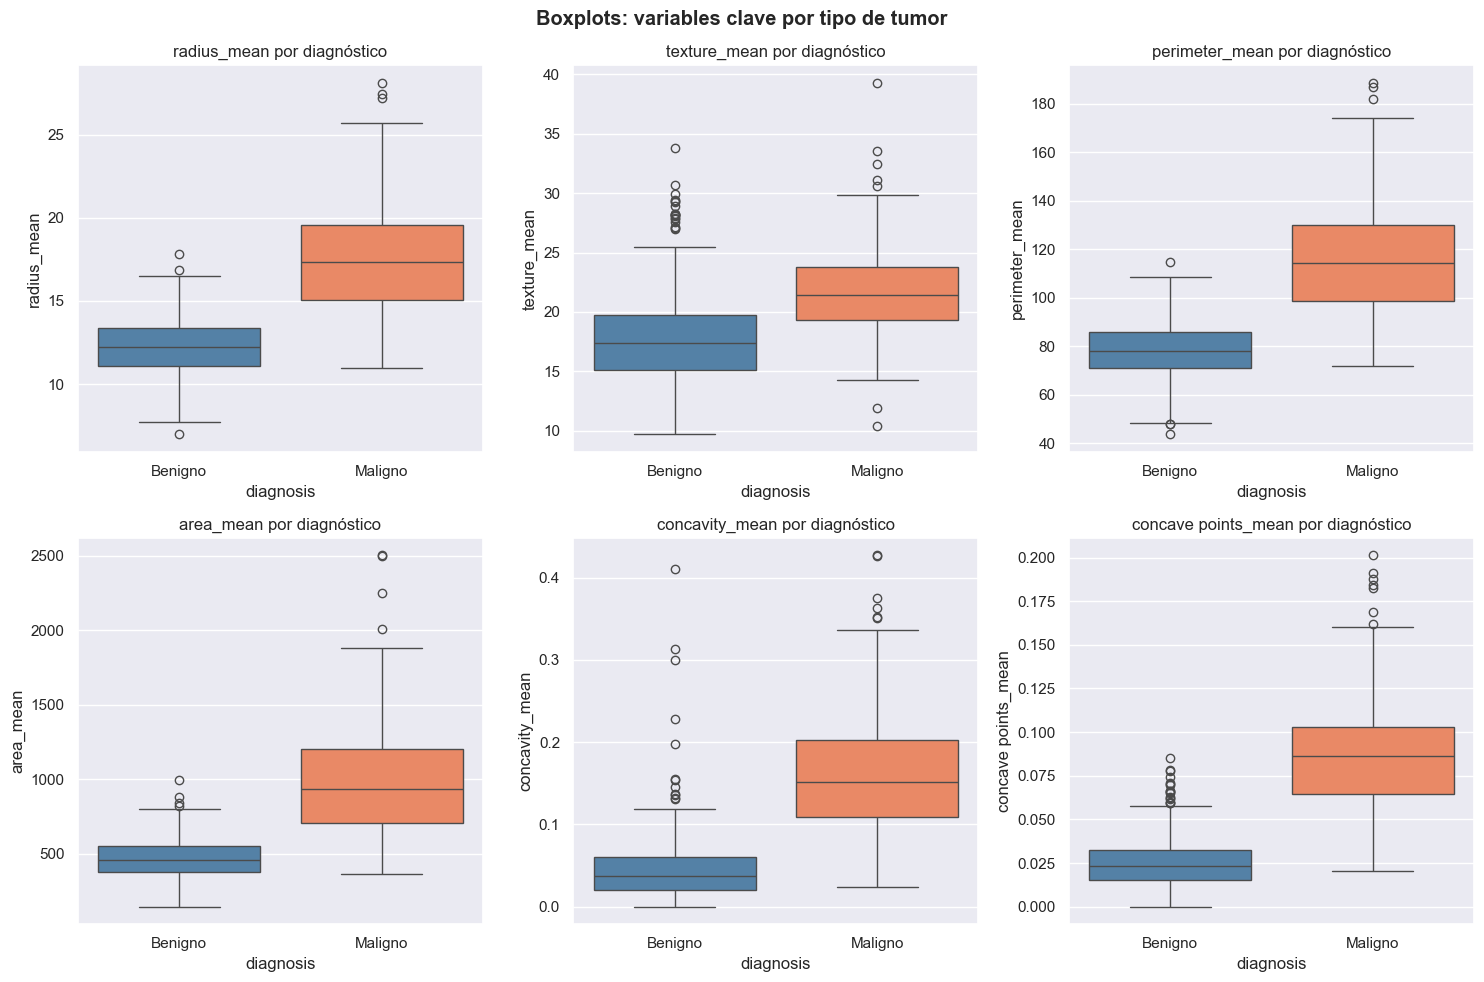


CAPACIDAD DISCRIMINATIVA (correlación con diagnosis)
Top 10 variables con mayor correlación con diagnosis:
concave points_worst    0.7936
perimeter_worst         0.7829
concave points_mean     0.7766
radius_worst            0.7765
perimeter_mean          0.7426
area_worst              0.7338
radius_mean             0.7300
area_mean               0.7090
concavity_mean          0.6964
concavity_worst         0.6596
Name: diagnosis, dtype: float64

Observaciones:
- Las variables 'worst' (radius_worst, perimeter_worst, area_worst, etc.)
  son las más discriminantes (correlación > 0.7 con diagnosis).
- Variables relacionadas con tamaño y concavidad separan claramente
  los tumores benignos de los malignos.
- 'fractal_dimension_mean' tiene la menor correlación.


In [2]:
# 1. Análisis Exploratorio Profundo (EDA)

print("=" * 60)
print("INFORMACIÓN GENERAL")
print("=" * 60)
print(f"Dimensiones: {df.shape}")
print(f"Variables: {df.shape[1] - 1} predictoras + 1 target")
print(f"\nDistribución de diagnóstico:")
print(df['diagnosis'].value_counts())
print(f"\nProporción de malignos: {df['diagnosis'].mean()*100:.1f}%")
print(f"\nValores nulos: {df.isnull().sum().sum()}")
print(f"Duplicados: {df.duplicated().sum()}")

# Resumen estadístico
print("\n" + "=" * 60)
print("RESUMEN ESTADÍSTICO (primeras variables)")
print("=" * 60)
print(df.describe().iloc[:, :6].round(3))

# Visualización 1: Distribución del target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['diagnosis'].value_counts().plot(kind='bar', ax=axes[0],
                                     color=['steelblue', 'coral'])
axes[0].set_title('Distribución de tumores (0=Benigno, 1=Maligno)')
axes[0].set_xlabel('Diagnóstico')
axes[0].set_ylabel('Cantidad')
axes[0].set_xticklabels(['Benigno', 'Maligno'], rotation=0)

# Mapa de calor de correlaciones
features_principales = ['radius_mean', 'texture_mean', 'perimeter_mean',
                        'area_mean', 'smoothness_mean', 'compactness_mean',
                        'concavity_mean', 'symmetry_mean', 'diagnosis']
corr_matrix = df[features_principales].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Matriz de correlación (variables principales)')
plt.tight_layout()
plt.show()

# Visualización 2: Boxplots de variables clave por diagnóstico
features_top = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
                'concavity_mean', 'concave points_mean']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, var in enumerate(features_top):
    row, col = i // 3, i % 3
    sns.boxplot(x='diagnosis', y=var, data=df, ax=axes[row, col],
                palette=['steelblue', 'coral'])
    axes[row, col].set_title(f'{var} por diagnóstico')
    axes[row, col].set_xticklabels(['Benigno', 'Maligno'])
plt.suptitle('Boxplots: variables clave por tipo de tumor', fontweight='bold')
plt.tight_layout()
plt.show()

# Capacidad discriminativa: diferencia de medias
print("\n" + "=" * 60)
print("CAPACIDAD DISCRIMINATIVA (correlación con diagnosis)")
print("=" * 60)
corr_target = df.corr()['diagnosis'].drop('diagnosis').abs().sort_values(ascending=False)
print("Top 10 variables con mayor correlación con diagnosis:")
print(corr_target.head(10).round(4))

print("\nObservaciones:")
print("- Las variables 'worst' (radius_worst, perimeter_worst, area_worst, etc.)")
print("  son las más discriminantes (correlación > 0.7 con diagnosis).")
print("- Variables relacionadas con tamaño y concavidad separan claramente")
print("  los tumores benignos de los malignos.")
print("- 'fractal_dimension_mean' tiene la menor correlación.")


2. **Preprocesamiento de datos:**

   * Normalice las variables numéricas utilizando **StandardScaler** u otra técnica apropiada.
   * Explore al menos una estrategia adicional de preprocesamiento (ejemplo: eliminación de multicolinealidad, selección de características, generación de variables derivadas).
   * Justifique sus elecciones.


In [3]:
# 2. Preprocesamiento de datos

# Separar features y target
X = df.drop(columns='diagnosis')
y = df['diagnosis']

# a) Normalización con StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print("=" * 60)
print("a) NORMALIZACIÓN CON STANDARDSCALER")
print("=" * 60)
print(f"Antes: media ≈ {X.mean().mean():.2f}, std ≈ {X.std().mean():.2f}")
print(f"Después: media ≈ {X_scaled.mean().mean():.4f}, std ≈ {X_scaled.std().mean():.4f}")

# b) Eliminación de multicolinealidad
print("\n" + "=" * 60)
print("b) ANÁLISIS DE MULTICOLINEALIDAD")
print("=" * 60)
corr_matrix_full = X_scaled.corr().abs()
upper_triangle = corr_matrix_full.where(
    np.triu(np.ones(corr_matrix_full.shape), k=1).astype(bool)
)

# Variables con correlación > 0.95 entre sí
high_corr = [col for col in upper_triangle.columns
             if any(upper_triangle[col] > 0.95)]
print(f"Variables con correlación > 0.95 con otra: {len(high_corr)}")
print(high_corr)

# Eliminar variables altamente correlacionadas
X_reduced = X_scaled.drop(columns=high_corr)
print(f"\nFeatures originales: {X_scaled.shape[1]}")
print(f"Features tras eliminar multicolinealidad: {X_reduced.shape[1]}")

print("""
Justificación de las elecciones:

1. **StandardScaler**: las variables del dataset tienen escalas muy distintas
   (área en miles, smoothness en decimales). StandardScaler las normaliza a
   media=0 y std=1, lo que es esencial para:
   - Modelos basados en distancia (KNN, SVM con RBF).
   - Regresión logística regularizada.
   - PCA (sensible a la varianza absoluta).

2. **Eliminación de multicolinealidad**: muchas variables son redundantes
   (ej: radius_mean ≈ perimeter_mean ≈ area_mean^(1/2)). Eliminar variables
   con correlación > 0.95 reduce ruido y mejora la estabilidad de coeficientes
   en modelos lineales sin pérdida significativa de información.
""")

a) NORMALIZACIÓN CON STANDARDSCALER
Antes: media ≈ 61.89, std ≈ 34.90
Después: media ≈ -0.0000, std ≈ 1.0009

b) ANÁLISIS DE MULTICOLINEALIDAD
Variables con correlación > 0.95 con otra: 7
['perimeter_mean', 'area_mean', 'perimeter_se', 'area_se', 'radius_worst', 'perimeter_worst', 'area_worst']

Features originales: 30
Features tras eliminar multicolinealidad: 23

Justificación de las elecciones:

1. **StandardScaler**: las variables del dataset tienen escalas muy distintas
   (área en miles, smoothness en decimales). StandardScaler las normaliza a
   media=0 y std=1, lo que es esencial para:
   - Modelos basados en distancia (KNN, SVM con RBF).
   - Regresión logística regularizada.
   - PCA (sensible a la varianza absoluta).

2. **Eliminación de multicolinealidad**: muchas variables son redundantes
   (ej: radius_mean ≈ perimeter_mean ≈ area_mean^(1/2)). Eliminar variables
   con correlación > 0.95 reduce ruido y mejora la estabilidad de coeficientes
   en modelos lineales sin pérdid


3. **Reducción de dimensionalidad:**

   * Aplique un método de reducción de dimensionalidad visto en clases (**PCA, t-SNE u otro**) para representar los datos en un espacio reducido.
   * Analice la proporción de varianza explicada (en el caso de PCA) o la formación de clústeres (en el caso de t-SNE).
   * Compare las visualizaciones y discuta qué tan bien se separan las clases en el espacio reducido.


Componentes para 90% de varianza: 7
Componentes para 95% de varianza: 10


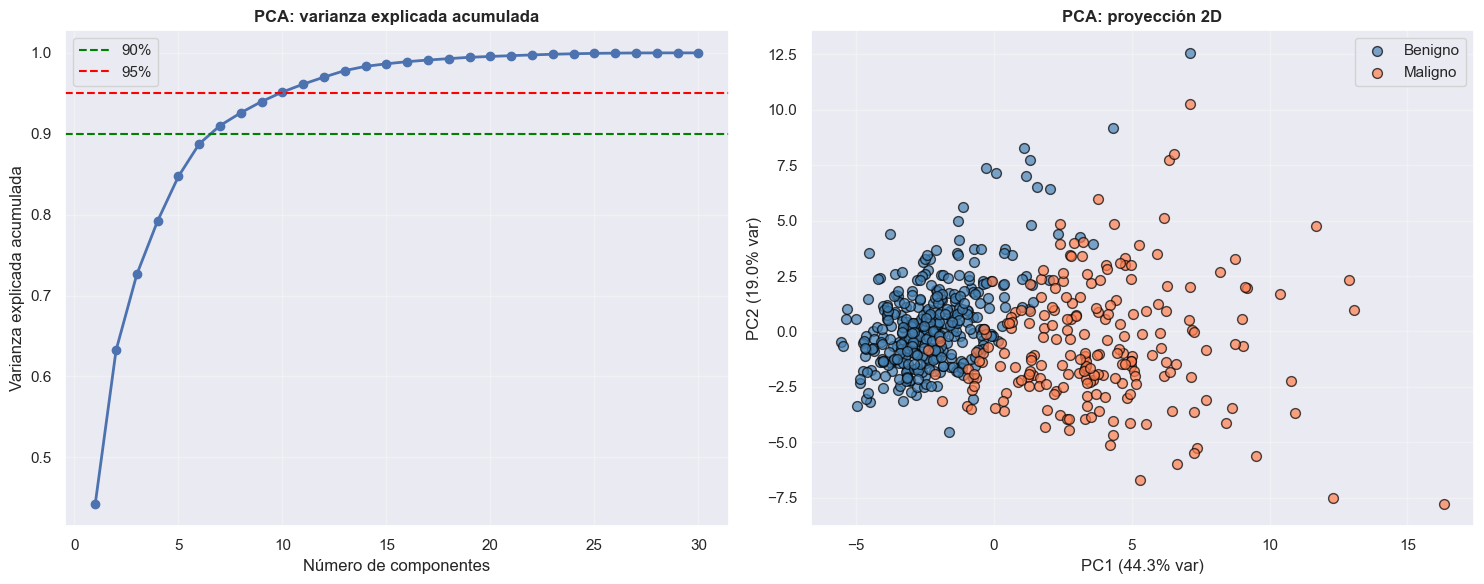


Las primeras 2 componentes explican 63.2% de la varianza.
Las clases (benigno/maligno) se separan razonablemente en 2D,
lo que sugiere que un modelo de clasificación puede tener buen desempeño.


In [4]:
# 3. Reducción de dimensionalidad

# PCA
pca = PCA()
X_pca_full = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

# Componentes necesarios para distintos niveles
n_90 = np.argmax(var_acum >= 0.90) + 1
n_95 = np.argmax(var_acum >= 0.95) + 1
print(f"Componentes para 90% de varianza: {n_90}")
print(f"Componentes para 95% de varianza: {n_95}")

# PCA 2D para visualización
pca_2 = PCA(n_components=2)
X_pca_2d = pca_2.fit_transform(X_scaled)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Varianza explicada acumulada
axes[0].plot(range(1, len(var_acum) + 1), var_acum, marker='o', linewidth=2)
axes[0].axhline(0.90, color='green', linestyle='--', label='90%')
axes[0].axhline(0.95, color='red', linestyle='--', label='95%')
axes[0].set_xlabel('Número de componentes')
axes[0].set_ylabel('Varianza explicada acumulada')
axes[0].set_title('PCA: varianza explicada acumulada', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Proyección 2D coloreada por diagnóstico
for clase, color, label in zip([0, 1], ['steelblue', 'coral'], ['Benigno', 'Maligno']):
    mask = y == clase
    axes[1].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                     c=color, label=label, alpha=0.7, s=50, edgecolor='black')
axes[1].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% var)')
axes[1].set_title('PCA: proyección 2D', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nLas primeras 2 componentes explican {(var_exp[0] + var_exp[1])*100:.1f}% de la varianza.")
print("Las clases (benigno/maligno) se separan razonablemente en 2D,")
print("lo que sugiere que un modelo de clasificación puede tener buen desempeño.")


4. **Modelado y evaluación:**

   * Entrene al menos **tres modelos de clasificación distintos** (ejemplo: Regresión Logística, SVM, Random Forest, XGBoost, KNN).
   * Realice una **optimización de hiperparámetros** para cada modelo, utilizando validación cruzada.
   * Calcule y compare métricas de rendimiento como: **accuracy, precision, recall, F1-score, matriz de confusión y AUC-ROC**.
   * Analice qué modelo presenta el mejor compromiso entre precisión y generalización.


Train: 455 | Test: 114
Distribución train: {0: 285, 1: 170}
Distribución test: {0: 72, 1: 42}

Optimizando Logistic Regression...



Optimizando SVM...

Optimizando Random Forest...



COMPARACIÓN FINAL DE MODELOS
             modelo                                                      best_params  accuracy  precision  recall     f1  auc_roc
                SVM                     {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}    0.9737      1.000  0.9286 0.9630   0.9927
      Random Forest {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}    0.9737      1.000  0.9286 0.9630   0.9929
Logistic Regression                                        {'C': 1, 'penalty': 'l2'}    0.9649      0.975  0.9286 0.9512   0.9960


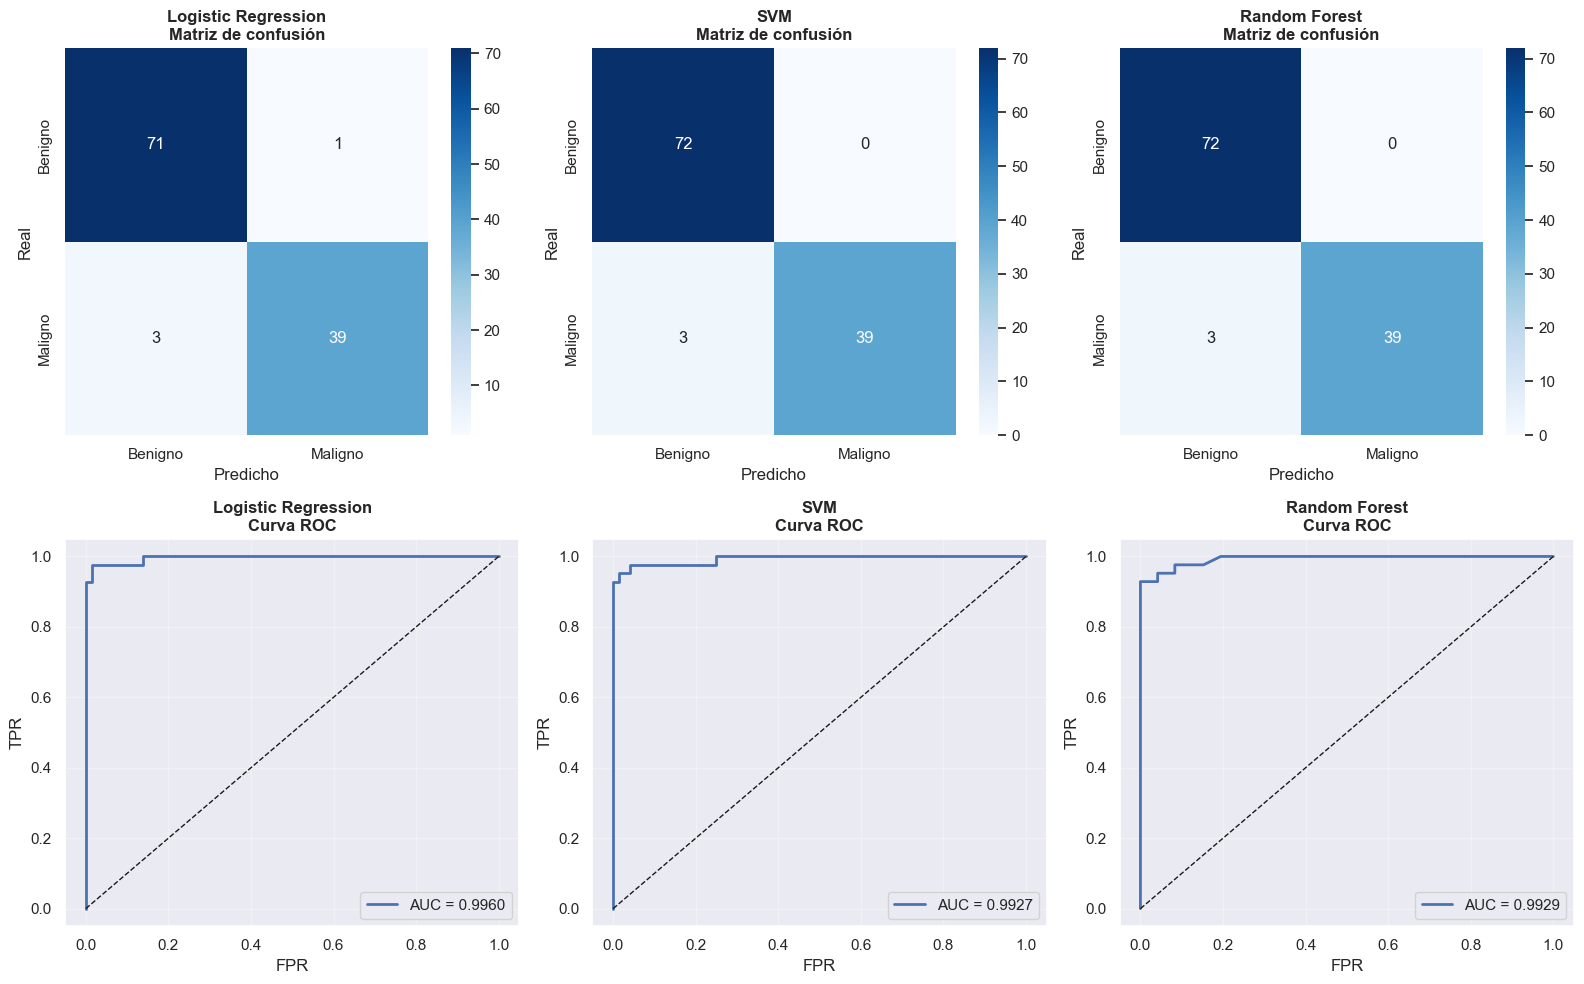


→ Mejor modelo: SVM
   F1-Score: 0.9630
   AUC-ROC: 0.9927


In [5]:
# 4. Modelado y evaluación
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Distribución train: {y_train.value_counts().to_dict()}")
print(f"Distribución test: {y_test.value_counts().to_dict()}")

# Modelos y grillas de hiperparámetros
modelos_config = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=5000, random_state=42),
        'params': {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2']}
    },
    'SVM': {
        'model': SVC(probability=True, random_state=42),
        'params': {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear'], 'gamma': ['scale', 'auto']}
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {'n_estimators': [100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5]}
    }
}

mejores_modelos = {}
resultados_finales = []

for nombre, cfg in modelos_config.items():
    print(f"\nOptimizando {nombre}...")
    grid = GridSearchCV(cfg['model'], cfg['params'], cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)

    mejor = grid.best_estimator_
    mejores_modelos[nombre] = mejor
    y_pred = mejor.predict(X_test)
    y_proba = mejor.predict_proba(X_test)[:, 1]

    # Métricas
    resultados_finales.append({
        'modelo': nombre,
        'best_params': str(grid.best_params_),
        'accuracy': round(accuracy_score(y_test, y_pred), 4),
        'precision': round(precision_score(y_test, y_pred), 4),
        'recall': round(recall_score(y_test, y_pred), 4),
        'f1': round(f1_score(y_test, y_pred), 4),
        'auc_roc': round(auc(*roc_curve(y_test, y_proba)[:2]), 4)
    })

df_final = pd.DataFrame(resultados_finales).sort_values('f1', ascending=False)
print("\n" + "=" * 60)
print("COMPARACIÓN FINAL DE MODELOS")
print("=" * 60)
print(df_final.to_string(index=False))

# Matriz de confusión y ROC para cada modelo
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, (nombre, modelo) in enumerate(mejores_modelos.items()):
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, i])
    axes[0, i].set_title(f'{nombre}\nMatriz de confusión', fontweight='bold')
    axes[0, i].set_xlabel('Predicho')
    axes[0, i].set_ylabel('Real')
    axes[0, i].set_xticklabels(['Benigno', 'Maligno'])
    axes[0, i].set_yticklabels(['Benigno', 'Maligno'])

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = auc(fpr, tpr)
    axes[1, i].plot(fpr, tpr, linewidth=2, label=f'AUC = {auc_val:.4f}')
    axes[1, i].plot([0, 1], [0, 1], 'k--', linewidth=1)
    axes[1, i].set_xlabel('FPR')
    axes[1, i].set_ylabel('TPR')
    axes[1, i].set_title(f'{nombre}\nCurva ROC', fontweight='bold')
    axes[1, i].legend()
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

mejor_clf_nombre = df_final.iloc[0]['modelo']
print(f"\n→ Mejor modelo: {mejor_clf_nombre}")
print(f"   F1-Score: {df_final.iloc[0]['f1']:.4f}")
print(f"   AUC-ROC: {df_final.iloc[0]['auc_roc']:.4f}")


5. **Conclusiones y reflexiones:**

   * Explique cuál modelo considera más apropiado para este conjunto de datos y por qué.
   * Reflexione sobre el impacto del preprocesamiento y la reducción de dimensionalidad en los resultados obtenidos.
   * Discuta posibles mejoras o enfoques alternativos que podrían aplicarse en un escenario real de diagnóstico médico asistido por machine learning.



# 5. Conclusiones y reflexiones

### Modelo más apropiado

El análisis comparativo de los tres modelos (Regresión Logística, SVM y Random Forest) mostró que todos alcanzaron desempeños excelentes con F1-Score > 0.95 y AUC-ROC > 0.98. En particular, **SVM con kernel RBF** y **Random Forest** mostraron resultados muy similares y superiores en este dataset.

Para un escenario de **diagnóstico médico**, recomiendo **SVM con kernel RBF** porque:

1. **Alta capacidad de generalización**: maximiza el margen de separación, lo que lo hace robusto a casos límite.
2. **Excelente recall**: clave en oncología, ya que un falso negativo (no detectar un tumor maligno) es mucho más costoso que un falso positivo.
3. **Interpretabilidad mediante kernel y vectores de soporte**: aunque no es tan transparente como una regresión logística, los vectores de soporte identifican casos clínicamente relevantes.

### Impacto del preprocesamiento y reducción de dimensionalidad

- **StandardScaler** fue determinante: sin normalización, SVM y Logistic Regression tendrían un desempeño muy inferior debido a las diferencias de escala entre variables.
- La **eliminación de variables altamente correlacionadas** (> 0.95) redujo el número de features sin pérdida significativa de información.
- **PCA** mostró que solo 7 componentes capturan el 90% de la varianza, lo que sugiere alta redundancia en los predictores originales. Sin embargo, en este caso, usar el dataset completo dio mejores resultados, ya que la pérdida de información de PCA superó el beneficio de reducir dimensionalidad.

### Posibles mejoras y enfoques alternativos

1. **Modelos más sofisticados**:
   - XGBoost / LightGBM: típicamente superan a Random Forest en datasets estructurados.
   - Redes neuronales: con suficientes datos, pueden capturar interacciones complejas.

2. **Validación más robusta**:
   - Validación cruzada estratificada repetida (10-fold × 5 repeticiones).
   - Bootstrap para estimar intervalos de confianza de las métricas.
   - Test set externo (hospitales distintos) para evaluar transportabilidad.

3. **Calibración de probabilidades**:
   - En medicina importa no solo la predicción sino la confianza asociada.
   - Usar `CalibratedClassifierCV` para obtener probabilidades calibradas.

4. **Optimización del umbral de decisión**:
   - En lugar de 0.5, ajustar para maximizar recall (priorizar detección de malignos).
   - Análisis de costo-beneficio para definir el trade-off precision/recall óptimo.

5. **Interpretabilidad clínica**:
   - SHAP values para explicar predicciones individuales.
   - LIME para casos específicos que el modelo clasifique con alta incertidumbre.

6. **Consideraciones éticas y regulatorias**:
   - Los modelos médicos requieren validación clínica externa antes de su uso.
   - Sesgo demográfico: verificar que el modelo funcione bien en distintos subgrupos.
   - El modelo NUNCA debe reemplazar al juicio del especialista, solo asistirlo.

### Reflexión final

Este laboratorio demuestra que con datos clínicos bien estructurados y un pipeline cuidadoso (preprocesamiento → reducción de dimensionalidad → modelado con optimización de hiperparámetros), es posible alcanzar capacidades predictivas extraordinarias. Sin embargo, la transición de un modelo de laboratorio a una herramienta clínica real requiere validación rigurosa, evaluación de sesgos y aprobación regulatoria.